# 01 — Build Optic Lobe mcHH Model from Packed Simplified Morphologies

当前 notebook 统一作为 **optic lobe mcHH** 的主入口。

目标：

- 读取按 neuron type 打包的 `.bin` 形态文件
- 显示加载进度（多少 neurons）和内存占用
- 接到现有 `FAFBMCNetwork` 构建流程
- 暂时仍使用 shared morphology 做仿真，但同时把每个 neuron 的简化形态元数据挂到 network 上，方便下一步升级为真正 per-neuron mcHH


In [1]:
import sys, os, time, logging
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from neuro_framework.models import (
    PackedMorphologyLoader,
    estimate_package_memory,
    load_or_build_cached_net,
    apply_postbuild_parameter_overrides,
    build_pathway_override_rules,
    build_per_neuron_table,
    run_flash_sanity,
    summarize_flash_by_type,
    mode_or_na,
)

print(f'PyTorch {torch.__version__}')


PyTorch 2.2.0


## 1. Paths


In [2]:
DATA_DIR = '../../mcHH/data/optic_lobe_right'
MORPH_PKG_DIR = '../../mcHH/data/optic_lobe_type_packages_v1'
ION_RULES = '../data/ion_channel_rules.csv'
SYN_RULES = '../data/synapse_rules.csv'
NT_ION_RULES = None
ROOT_ION_OVERRIDES = None

DT = 0.1
NCOMP = 2
MIN_SYN_COUNT = 3
MORPH_PROGRESS_EVERY = 5000

CACHE_DIR = '../../mcHH/data/cache'
NET_CACHE_PATH = f'{CACHE_DIR}/optic_lobe_net_type_rules_v3.pt'
FORCE_REBUILD = False
SAVE_CACHE_AFTER_BUILD = True

SANITY_T_PRE = 40.0
SANITY_T_ON = 10.0
SANITY_T_OFF = 30.0
SANITY_STABILITY_SECONDS = 180.0
SANITY_I_AMP = 30.0
STRONG_SANITY_I_AMP = 60.0

R16_ELEAK_SHIFT_MV = -10.0  # make R1-6 resting potential more negative before stimulus
R16_VTH_SHIFT_MV = 8.0  # default shift for most R1-6 outputs
R16_TARGET_VTH_SHIFTS_MV = {'L1': -4.0, 'L3': -4.0}  # keep lamina inhibition more available than other outputs
R16_TARGET_GS_GAINS = {'L1': 1.5, 'L3': 1.25}  # strengthen key lamina inhibitory drive
R16_SYNAPSE_GAIN = 1.0  # try 1.5-2.0 if R1-6 output remains too weak after equilibration
SANITY_PROGRESS_EVERY = 50

SUMMARY_TYPES = ['R1-6', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Tm3', 'T4a', 'T5a']
MAX_SINGLE_NEURON_TRACES_PER_TYPE = 3
MORPH_SAMPLE_LIMIT = 300

print('DATA_DIR            =', DATA_DIR)
print('MORPH_PKG_DIR       =', MORPH_PKG_DIR)
print('ION_RULES           =', ION_RULES)
print('SYN_RULES           =', SYN_RULES)
print('NT_ION_RULES        =', NT_ION_RULES)
print('ROOT_ION_OVERRIDES  =', ROOT_ION_OVERRIDES)
print('NET_CACHE_PATH      =', NET_CACHE_PATH)
print('DT, NCOMP           =', DT, NCOMP)
print('MIN_SYN_COUNT       =', MIN_SYN_COUNT)

print('R16_ELEAK_SHIFT_MV  =', R16_ELEAK_SHIFT_MV)
print('R16_VTH_SHIFT_MV    =', R16_VTH_SHIFT_MV)
print('R16_TARGET_VTH_SHIFTS_MV =', R16_TARGET_VTH_SHIFTS_MV)
print('R16_TARGET_GS_GAINS      =', R16_TARGET_GS_GAINS)


DATA_DIR            = ../../mcHH/data/optic_lobe_right
MORPH_PKG_DIR       = ../../mcHH/data/optic_lobe_type_packages_v1
ION_RULES           = ../data/ion_channel_rules.csv
SYN_RULES           = ../data/synapse_rules.csv
NT_ION_RULES        = None
ROOT_ION_OVERRIDES  = None
NET_CACHE_PATH      = ../../mcHH/data/cache/optic_lobe_net_type_rules_v3.pt
DT, NCOMP           = 0.1 2
MIN_SYN_COUNT       = 3
R16_ELEAK_SHIFT_MV  = -10.0
R16_VTH_SHIFT_MV    = 8.0
R16_TARGET_VTH_SHIFTS_MV = {'L1': -4.0, 'L3': -4.0}
R16_TARGET_GS_GAINS      = {'L1': 1.5, 'L3': 1.25}


## 2. Inspect packed morphology packages


In [3]:
loader = PackedMorphologyLoader(MORPH_PKG_DIR)
mem_est = estimate_package_memory(MORPH_PKG_DIR)

print(f"Total packaged neurons : {loader.total_neurons:,}")
print(f"Total packages         : {loader.total_groups:,}")
print(f"Estimated node payload : {mem_est['estimated_node_payload_mb']:.1f} MB")

pkg_df = pd.DataFrame(loader.package_summary())
display(pkg_df.head(12))

type_counts = pd.Series(loader.type_counts()).sort_values(ascending=False)
display(type_counts.head(20).to_frame('count'))


Total packaged neurons : 95,078
Total packages         : 309
Estimated node payload : 1785.4 MB


,group_name,bin_file,index_file,neuron_count,types,mode,prefix,count
0,rare_mixed__AN,rare_mixed__AN.bin,rare_mixed__AN.index.json,9,"[AN_multi_124, AN_multi_125]",rare_mixed_prefix,AN,9
1,rare_mixed__AOTU,rare_mixed__AOTU.bin,rare_mixed__AOTU.index.json,3,"[AOTU026, AOTU054, AOTU065]",rare_mixed_prefix,AOTU,3
2,rare_mixed__APDN,rare_mixed__APDN.bin,rare_mixed__APDN.index.json,12,[APDN3],rare_mixed_prefix,APDN,12
3,rare_mixed__AVLP,rare_mixed__AVLP.bin,rare_mixed__AVLP.index.json,4,"[AVLP151, AVLP534, AVLP593]",rare_mixed_prefix,AVLP,4
4,rare_mixed__Am,rare_mixed__Am.bin,rare_mixed__Am.index.json,2,[Am1],rare_mixed_prefix,Am,2
5,rare_mixed__CB,rare_mixed__CB.bin,rare_mixed__CB.index.json,28,"[CB0143, CB0230, CB0734, CB0802, CB1329, CB219...",rare_mixed_prefix,CB,28
6,rare_mixed__CL,rare_mixed__CL.bin,rare_mixed__CL.index.json,1,[CL104],rare_mixed_prefix,CL,1
7,rare_mixed__CT,rare_mixed__CT.bin,rare_mixed__CT.index.json,2,[CT1],rare_mixed_prefix,CT,2
8,rare_mixed__DCH,rare_mixed__DCH.bin,rare_mixed__DCH.index.json,2,[DCH],rare_mixed_prefix,DCH,2
9,rare_mixed__DGI,rare_mixed__DGI.bin,rare_mixed__DGI.index.json,2,[DGI],rare_mixed_prefix,DGI,2


,count
R1-6,7172
T2a,1774
Tm3,1755
T4c,1710
T3,1676
L2,1639
L1,1627
Mi1,1581
L5,1580
T4d,1569


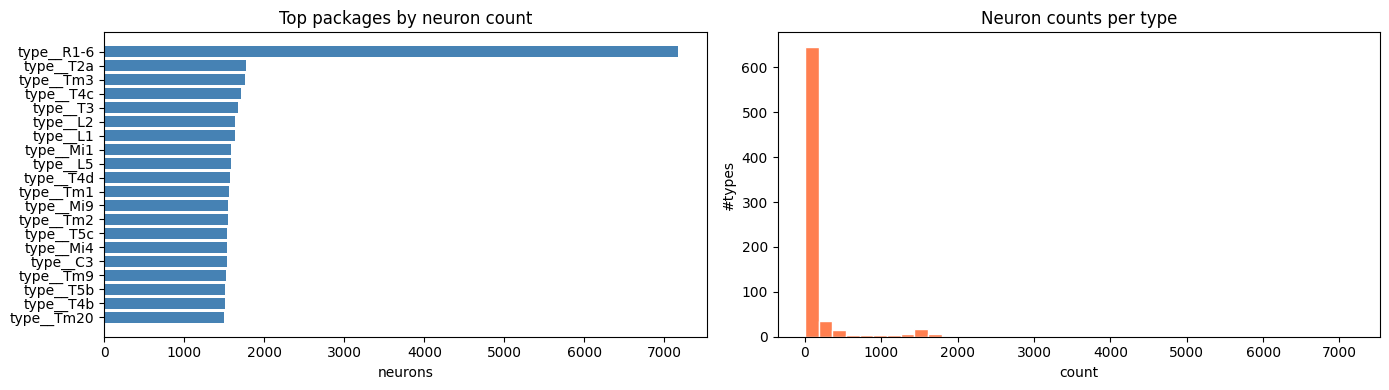

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_pkg = pkg_df.sort_values('neuron_count', ascending=False).head(20)
axes[0].barh(top_pkg['group_name'][::-1], top_pkg['neuron_count'][::-1], color='steelblue')
axes[0].set_title('Top packages by neuron count')
axes[0].set_xlabel('neurons')

axes[1].hist(type_counts.values, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Neuron counts per type')
axes[1].set_xlabel('count')
axes[1].set_ylabel('#types')

plt.tight_layout(); plt.show()


## 3. Build mcHH network and attach morphology packages


In [5]:
cache_meta = {
    'data_dir': DATA_DIR,
    'morph_pkg_dir': MORPH_PKG_DIR,
    'ion_rules': ION_RULES,
    'syn_rules': SYN_RULES,
    'dt': DT,
    'ncomp': NCOMP,
    'min_syn_count': MIN_SYN_COUNT,
}

net, loaded_cache_meta, loaded_from_cache, build_elapsed = load_or_build_cached_net(
    cache_path=NET_CACHE_PATH,
    force_rebuild=FORCE_REBUILD,
    save_cache_after_build=SAVE_CACHE_AFTER_BUILD,
    cache_meta=cache_meta,
    data_dir=DATA_DIR,
    morphology_package_dir=MORPH_PKG_DIR,
    ion_rules_path=ION_RULES,
    syn_rules_path=SYN_RULES,
    nt_ion_rules_path=NT_ION_RULES,
    neuron_ion_overrides_path=ROOT_ION_OVERRIDES,
    dt=DT,
    ncomp=NCOMP,
    min_syn_count=MIN_SYN_COUNT,
    morphology_progress_every=MORPH_PROGRESS_EVERY,
)
neuron_override_rules, synapse_override_rules = build_pathway_override_rules(
    eLeak_shift_mV=R16_ELEAK_SHIFT_MV,
    v_th_shift_mV=R16_VTH_SHIFT_MV,
    target_v_th_shifts_mV=R16_TARGET_VTH_SHIFTS_MV,
    target_gs_gains=R16_TARGET_GS_GAINS,
)
net = apply_postbuild_parameter_overrides(
    net,
    neuron_rules=neuron_override_rules,
    synapse_rules=synapse_override_rules,
    reset_first=True,
)
print('loaded_from_cache =', loaded_from_cache)
print('cache_meta =', loaded_cache_meta)


loaded_from_cache = True
cache_meta = {'data_dir': '../../mcHH/data/optic_lobe_right', 'morph_pkg_dir': '../../mcHH/data/optic_lobe_type_packages_v1', 'ion_rules': '../data/ion_channel_rules.csv', 'syn_rules': '../data/synapse_rules.csv', 'dt': 0.1, 'ncomp': 2, 'min_syn_count': 3}


In [6]:
for type in set(net.cell_types):
    print(type, '\t',len(net.get_indices_by_type(type))) 


Li10 	 92
Sm14 	 19
LC39 	 4
Li01 	 84
L2 	 791
LC45 	 12
MTe26 	 1
Sm06 	 81
Dm9 	 128
LTe38b 	 2
cM01b 	 1
MLt5 	 36
LTe04 	 1
CB1329 	 1
cM07 	 1
PLP252 	 1
cM06 	 1
MTe13 	 3
Sm40 	 2
Sm35 	 3
Dm17 	 4
LPi12 	 1
LC29 	 23
LCe08 	 4
MTe17 	 2
cM16 	 1
Li124_56 	 2
MTe24 	 1
LPT57 	 1
MTe36 	 1
MTe37 	 1
LT40 	 1
LC10b 	 43
DmDRA2 	 12
MTe40 	 1
LPLC4 	 54
L3 	 738
cM05 	 1
LC34 	 7
cL22c 	 1
C3 	 768
Tm34 	 37
LTe74 	 1
LTe46 	 1
MTe52 	 24
s-LNv 	 4
LT86 	 1
Sm02 	 195
LTe35 	 1
LTe63 	 3
T5a 	 743
Li12 	 21
LT78 	 4
MTe45 	 1
PLP051 	 1
LT79 	 1
Pm05 	 75
LPT48_vCal3 	 1
LC10a 	 121
LTe01 	 2
LT1b 	 1
T2a 	 866
LTe76 	 1
LT67 	 1
LPi01 	 16
T4b 	 748
Dm8b 	 197
Dm15 	 201
LTe66 	 3
Tm2 	 767
MTe27 	 1
LTe38a 	 4
MLt3 	 55
Pm12 	 2
LPT47_vCal2 	 1
CB3238 	 1
CT1 	 1
MTe44 	 1
LT73 	 2
PLP215 	 1
LPTe01 	 20
cMLLP01 	 1
Sm09 	 83
LC10e 	 51
LT74 	 2
Tm21 	 623
MTe29 	 1
cM08c 	 3
MTe02 	 38
LTe68 	 5
Sm32 	 29
Tlp14 	 29
PLP150a 	 1
cL20 	 1
LTe53 	 1
LC28a 	 56
cL05 	 1
VS7 	 1
MTe

In [7]:
print()
print(f'Build finished in {build_elapsed:.1f}s')
print(net)
print(f"Morphology mode: {getattr(net, 'morphology_graph_mode', 'shared')}")
print(f"Total compartments: {getattr(net, 'total_comp', net.n_comp):,}")
print(f"Max compartments / neuron: {getattr(net, 'n_comp', 0):,}")
print(f"Fallback morphologies: {getattr(net, 'morphology_fallback_count', 0):,}")
print(f'Loaded morphology metadata for {net.loaded_morphology_count:,} neurons')
print(f'Nonzero morphology counts: {(net.morphology_node_counts > 0).sum():,}')
print(f"Root-id overrides used: {getattr(net, 'root_ion_overrides_count', 0):,}")
override_summary = getattr(net, 'manual_override_summary', {})
print('Post-build override summary:', override_summary)



Build finished in 0.0s
FAFBMCNetwork(n_neurons=47291, total_comp=1423346, max_comp=6746, n_edges=1111323, n_photo=4751, trainable=5840363)
Morphology mode: per_neuron_global_sparse
Total compartments: 1,423,346
Max compartments / neuron: 6,746
Fallback morphologies: 1
Loaded morphology metadata for 47,291 neurons
Nonzero morphology counts: 47,291
Root-id overrides used: 0
Post-build override summary: {'neuron_rule_count': 1, 'synapse_rule_count': 5, 'unique_neurons_touched': 3437, 'unique_synapses_touched': 14912, 'neuron_rule_summaries': [{'cell_types': ['R1-6', 'R1-R6'], 'root_ids': [], 'updates': {'E_L': {'shift': -10.0}}, 'matched_neurons': 3437}], 'synapse_rule_summaries': [{'pre_cell_types': ['R1-6', 'R1-R6'], 'post_cell_types': [], 'pre_root_ids': [], 'post_root_ids': [], 'updates': {'syn_v_th': {'shift': 8.0}}, 'matched_synapses': 14912}, {'pre_cell_types': ['R1-6', 'R1-R6'], 'post_cell_types': ['L1'], 'pre_root_ids': [], 'post_root_ids': [], 'updates': {'syn_v_th': {'shift': 

## 3b. Ion parameter hierarchy audit

Priority order is: `neurotransmitter default -> neuron type default -> root_id override`.
The table below shows how many neurons used each source in the current build.


,count
nt:acetylcholine,10854
nt:glutamate,5645
type_fallback:T4a,5363
type_fallback:Tm3,4398
nt:gaba,3483
type:R1-6,3437
type_fallback:Mi1,3152
type_fallback:L5,1511
type:Tm3,858
type:Mi1,796


,count
acetylcholine,28982
glutamate,7151
gaba,6000
histamine,4748
unknown,348
da,28
oct,26
ser,8


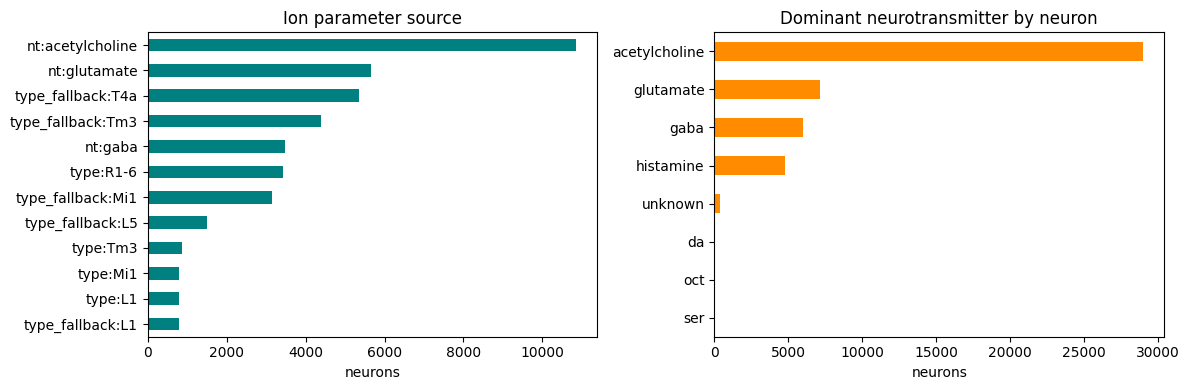

In [8]:
src_counts = pd.Series(net.neuron_param_source).value_counts()
display(src_counts.to_frame('count').head(20))

nt_counts = pd.Series(net.neuron_nt_types).value_counts()
display(nt_counts.to_frame('count'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
src_counts.head(12).sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Ion parameter source')
axes[0].set_xlabel('neurons')

nt_counts.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Dominant neurotransmitter by neuron')
axes[1].set_xlabel('neurons')
plt.tight_layout(); plt.show()


## 3c. Export per-type parameter audit table

导出每个 `type` 最终使用的参数层级、fallback 目标和 dominant neurotransmitter。


,raw_type,n_neurons,resolved_type,param_source,fallback_target,dominant_nt
0,R1-6,3437,R1-6,type:R1-6,None,histamine
1,T2a,866,T2a,type_fallback:Mi1,Mi1,acetylcholine
2,Tm3,858,Tm3,type:Tm3,None,acetylcholine
3,T4c,842,T4c,type_fallback:T4a,T4a,acetylcholine
4,T3,823,T3,type_fallback:Mi1,Mi1,acetylcholine
5,Mi1,796,Mi1,type:Mi1,None,acetylcholine
6,L1,793,L1,type:L1,None,glutamate
7,L2,791,L2,type_fallback:L1,L1,acetylcholine
8,L5,785,L5,type:L5,None,acetylcholine
9,T4d,777,T4d,type_fallback:T4a,T4a,acetylcholine


Saved: ../logs/optic_lobe_type_param_audit.csv


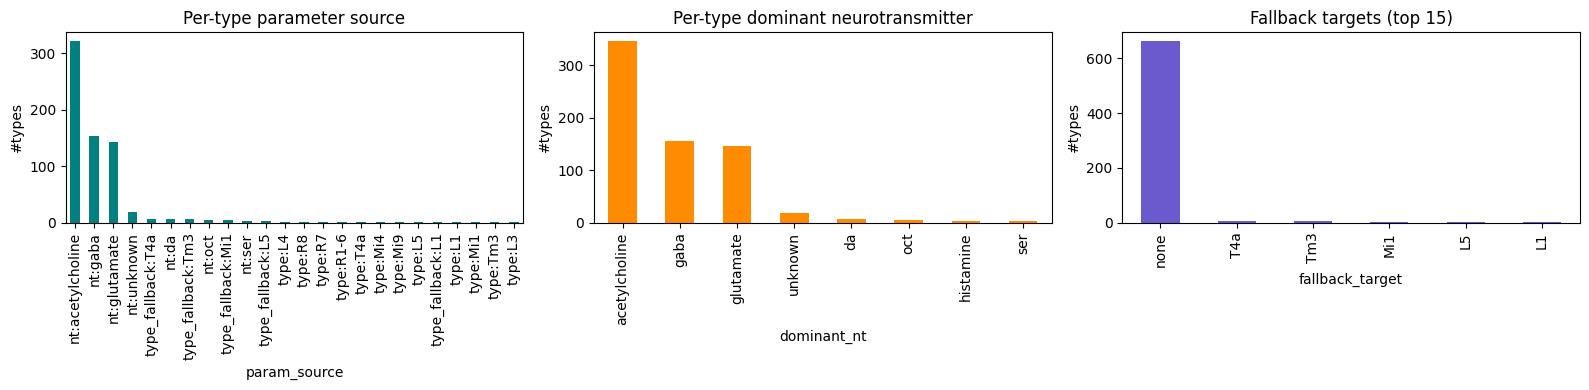

In [9]:
audit_df = pd.DataFrame({
    'root_id': net.root_ids,
    'raw_type': net.raw_cell_types,
    'resolved_type': net.resolved_cell_types,
    'param_source': net.neuron_param_source,
    'fallback_target': net.neuron_fallback_target,
    'dominant_nt': net.neuron_nt_types,
})

type_audit = audit_df.groupby('raw_type', as_index=False).agg(
    n_neurons=('root_id', 'count'),
    resolved_type=('resolved_type', mode_or_na),
    param_source=('param_source', mode_or_na),
    fallback_target=('fallback_target', mode_or_na),
    dominant_nt=('dominant_nt', mode_or_na),
)

type_audit = type_audit.sort_values(['n_neurons', 'raw_type'], ascending=[False, True]).reset_index(drop=True)
display(type_audit.head(40))

out_csv = '../logs/optic_lobe_type_param_audit.csv'
os.makedirs('../logs', exist_ok=True)
type_audit.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
type_audit['param_source'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Per-type parameter source')
axes[0].set_ylabel('#types')

type_audit['dominant_nt'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Per-type dominant neurotransmitter')
axes[1].set_ylabel('#types')

fb_counts = type_audit['fallback_target'].fillna('none').value_counts().head(15)
fb_counts.plot(kind='bar', ax=axes[2], color='slateblue')
axes[2].set_title('Fallback targets (top 15)')
axes[2].set_ylabel('#types')

plt.tight_layout(); plt.show()


## 3d. Export HH parameter table by neuron and by type

导出当前 build 后每个 neuron / type 实际使用的 HH 参数，方便之后和 response 一起对照。


In [10]:
per_neuron_param_df = build_per_neuron_table(net).rename(columns={
    'cell_type': 'raw_type',
    'resolved_cell_type': 'resolved_type',
    'n_solver_compartments': 'n_compartment_solver',
})
display(per_neuron_param_df.head())

per_type_param_df = per_neuron_param_df.groupby('raw_type', as_index=False).agg(
    n_neurons=('root_id', 'count'),
    resolved_type=('resolved_type', mode_or_na),
    dominant_nt=('dominant_nt', mode_or_na),
    param_source=('param_source', mode_or_na),
    fallback_target=('fallback_target', mode_or_na),
    gNa_mS_cm2=('gNa_mS_cm2', 'mean'),
    gK_mS_cm2=('gK_mS_cm2', 'mean'),
    gLeak_mS_cm2=('gLeak_mS_cm2', 'mean'),
    eNa_mV=('eNa_mV', 'mean'),
    eK_mV=('eK_mV', 'mean'),
    eLeak_mV=('eLeak_mV', 'mean'),
    n_compartment_solver_mean=('n_compartment_solver', 'mean'),
    n_swc_nodes_mean=('n_swc_nodes', 'mean'),
)
per_type_param_df = per_type_param_df.sort_values(['n_neurons', 'raw_type'], ascending=[False, True]).reset_index(drop=True)
display(per_type_param_df.head(40))

os.makedirs('../logs', exist_ok=True)
per_neuron_param_df.to_csv('../logs/optic_lobe_per_neuron_hh_params.csv', index=False)
per_type_param_df.to_csv('../logs/optic_lobe_per_type_hh_params.csv', index=False)
print('Saved: ../logs/optic_lobe_per_neuron_hh_params.csv')
print('Saved: ../logs/optic_lobe_per_type_hh_params.csv')


,neuron_idx,root_id,raw_type,resolved_type,dominant_nt,param_source,fallback_target,gNa_mS_cm2,gK_mS_cm2,gLeak_mS_cm2,eNa_mV,eK_mV,eLeak_mV,n_compartment_solver,n_swc_nodes
0,0,720575940596125868,T5c,T5c,acetylcholine,type_fallback:T4a,T4a,6.500000,2.0,1.6,50.0,-80.0,-60.0,18,538
1,1,720575940597856265,Tm16,Tm16,acetylcholine,nt:acetylcholine,None,3.500001,1.9,1.5,50.0,-77.0,-48.0,62,1274
2,2,720575940597944841,Tm7,Tm7,acetylcholine,nt:acetylcholine,None,3.500001,1.9,1.5,50.0,-77.0,-48.0,38,1172
3,3,720575940598267657,TmY15,TmY15,gaba,nt:gaba,None,2.500000,2.2,1.8,50.0,-77.0,-52.0,94,1654
4,4,720575940599333574,Tm1,Tm1,acetylcholine,type_fallback:Tm3,Tm3,8.000000,1.4,1.0,50.0,-80.0,-58.0,30,1168


,raw_type,n_neurons,resolved_type,dominant_nt,param_source,fallback_target,gNa_mS_cm2,gK_mS_cm2,gLeak_mS_cm2,eNa_mV,eK_mV,eLeak_mV,n_compartment_solver_mean,n_swc_nodes_mean
0,R1-6,3437,R1-6,histamine,type:R1-6,None,3.000000,2.400000,1.800000,50.0,-80.0,-78.000000,11.725924,123.410241
1,T2a,866,T2a,acetylcholine,type_fallback:Mi1,Mi1,7.000002,1.200000,1.200000,50.0,-80.0,-58.000000,21.642032,767.103926
2,Tm3,858,Tm3,acetylcholine,type:Tm3,None,8.000000,1.400000,1.000000,50.0,-80.0,-58.000000,17.158508,954.589744
3,T4c,842,T4c,acetylcholine,type_fallback:T4a,T4a,6.500000,2.000000,1.600000,50.0,-80.0,-60.000000,15.577197,602.958432
4,T3,823,T3,acetylcholine,type_fallback:Mi1,Mi1,7.000001,1.200000,1.200000,50.0,-80.0,-58.000000,23.997570,755.951397
5,Mi1,796,Mi1,acetylcholine,type:Mi1,None,7.000001,1.200000,1.200000,50.0,-80.0,-58.000000,19.321608,617.952261
6,L1,793,L1,glutamate,type:L1,None,2.000000,0.900000,1.200000,50.0,-80.0,-33.000000,18.562421,446.237074
7,L2,791,L2,acetylcholine,type_fallback:L1,L1,2.000000,0.900000,1.200000,50.0,-80.0,-33.000000,23.201011,491.390645
8,L5,785,L5,acetylcholine,type:L5,None,1.800000,1.100000,0.900000,50.0,-80.0,-34.000000,15.928662,726.166879
9,T4d,777,T4d,acetylcholine,type_fallback:T4a,T4a,6.500000,2.000000,1.600000,50.0,-80.0,-60.000000,14.169884,587.136422


Saved: ../logs/optic_lobe_per_neuron_hh_params.csv
Saved: ../logs/optic_lobe_per_type_hh_params.csv


Total neurons: 47,291, edges: 1,111,323, photoreceptors: 4,751
Total compartments: 1,423,346, max compartments/neuron: 6,746
Morphology fallback count: 1
Morphology nodes per neuron: mean=791.4, median=725.0, p95=1676.0


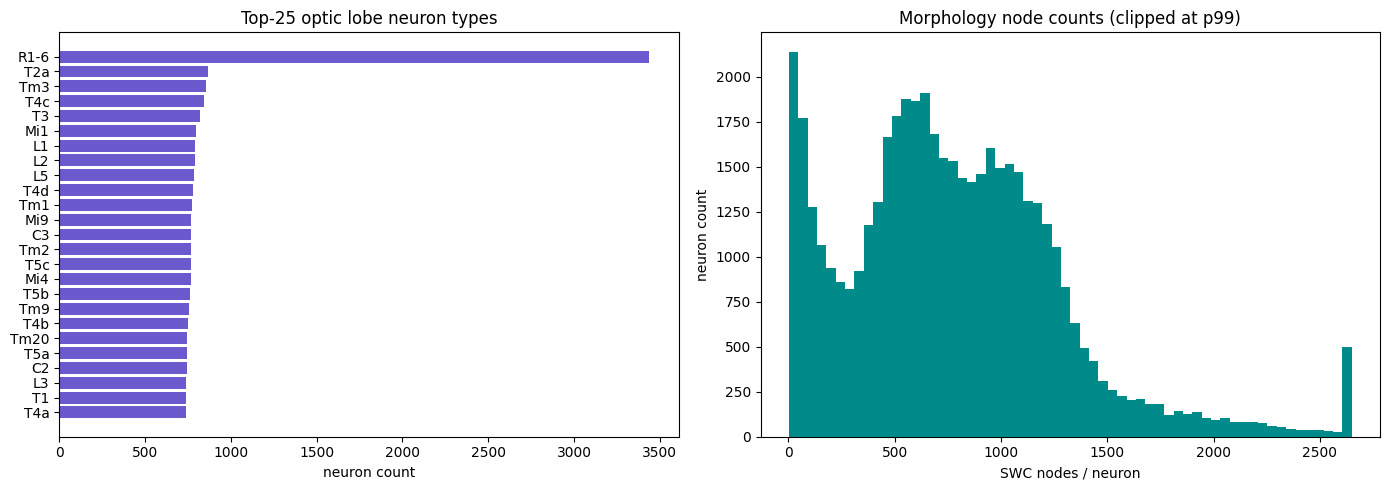

In [11]:
neurons_df = pd.read_csv(DATA_DIR + '/neurons.csv')
tc = net.type_counts()
print(f'Total neurons: {net.n_neurons:,}, edges: {net.n_edges:,}, photoreceptors: {net.input_mask.sum().item():,}')
print(f"Total compartments: {getattr(net, 'total_comp', net.n_comp):,}, max compartments/neuron: {net.n_comp:,}")
print(f"Morphology fallback count: {getattr(net, 'morphology_fallback_count', 0):,}")

morph_counts = pd.Series(net.morphology_node_counts)
nonzero_morph = morph_counts[morph_counts > 0]
print(f'Morphology nodes per neuron: mean={nonzero_morph.mean():.1f}, median={nonzero_morph.median():.1f}, p95={nonzero_morph.quantile(0.95):.1f}')

# Visualization is intentionally aggregated: plotting all neurons is too dense and too slow.
top_types = sorted(tc.items(), key=lambda x: -x[1])[:25]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([k for k, _ in top_types][::-1], [v for _, v in top_types][::-1], color='slateblue')
axes[0].set_title('Top-25 optic lobe neuron types')
axes[0].set_xlabel('neuron count')

axes[1].hist(nonzero_morph.clip(upper=nonzero_morph.quantile(0.99)), bins=60, color='darkcyan')
axes[1].set_title('Morphology node counts (clipped at p99)')
axes[1].set_xlabel('SWC nodes / neuron')
axes[1].set_ylabel('neuron count')
plt.tight_layout(); plt.show()


## 4. Sample morphology reads with progress + memory reporting

Only sample a small set for inspection. Full-neuron morphology visualization is not useful at optic-lobe scale.


In [12]:
sample_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']
sample_morphs = []
for morph in loader.iter_neurons(types=sample_types, limit=MORPH_SAMPLE_LIMIT, show_progress=True, progress_every=100):
    sample_morphs.append(morph)

print(f'Loaded {len(sample_morphs)} sample morphologies')
if sample_morphs:
    print('First sample:', sample_morphs[0].root_id, sample_morphs[0].neuron_type, sample_morphs[0].node_count)


Load morphologies:   0%|          | 0/300 [00:00<?, ?neuron/s]

loaded 100/300 neurons, nodes=32,225, RSS=878.0 MB, elapsed=0.0s
loaded 200/300 neurons, nodes=63,174, RSS=878.9 MB, elapsed=0.0s
loaded 300/300 neurons, nodes=94,260, RSS=879.7 MB, elapsed=0.0s
Loaded 300 sample morphologies
First sample: 720575940600322965 L1 354


,root_id,type,node_count,package
0,720575940600322965,L1,354,type__L1.bin
1,720575940602857696,L1,254,type__L1.bin
2,720575940604525792,L1,172,type__L1.bin
3,720575940604635616,L1,101,type__L1.bin
4,720575940604738016,L1,68,type__L1.bin


,type,n,node_mean,node_median,node_p95
0,L1,300,314.2,177.5,938.4


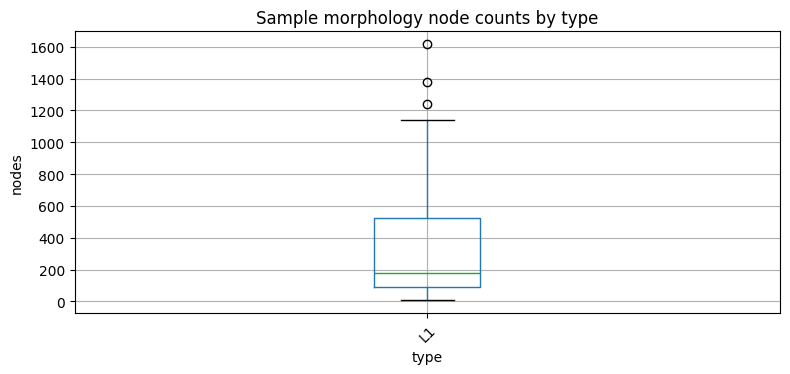

In [13]:
sample_df = pd.DataFrame({
    'root_id': [m.root_id for m in sample_morphs],
    'type': [m.neuron_type for m in sample_morphs],
    'node_count': [m.node_count for m in sample_morphs],
    'package': [m.package for m in sample_morphs],
})
display(sample_df.head())

type_summary = sample_df.groupby('type', as_index=False).agg(
    n=('root_id', 'count'),
    node_mean=('node_count', 'mean'),
    node_median=('node_count', 'median'),
    node_p95=('node_count', lambda x: x.quantile(0.95)),
)
display(type_summary.sort_values('node_median', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
sample_df.boxplot(column='node_count', by='type', ax=ax, rot=45)
ax.set_title('Sample morphology node counts by type')
ax.set_ylabel('nodes')
plt.suptitle('')
plt.tight_layout(); plt.show()


## 5. Stability-first flash sanity check

Run a short no-grad simulation first and extend only until the network appears stable. This avoids storing every compartment and only records soma voltages. If `R1-6` is weak but stable, rerun with `STRONG_SANITY_I_AMP`.


In [14]:
SANITY_I_AMP = 300.0


In [15]:
V, sanity_summary, flash_meta = run_flash_sanity(
    net,
    amp=SANITY_I_AMP,
    t_pre=SANITY_T_PRE,
    t_on=SANITY_T_ON,
    t_off=SANITY_T_OFF,
    stable_seconds=SANITY_STABILITY_SECONDS,
    dt=DT,
    progress_every=SANITY_PROGRESS_EVERY,
    stop_on_nan=True,
    r16_synapse_gain=R16_SYNAPSE_GAIN,
)
print(sanity_summary)

# V_strong, sanity_summary_strong, flash_meta_strong = run_flash_sanity(
#     net, amp=STRONG_SANITY_I_AMP, t_pre=SANITY_T_PRE, t_on=SANITY_T_ON, t_off=SANITY_T_OFF,
#     stable_seconds=SANITY_STABILITY_SECONDS, dt=DT, progress_every=SANITY_PROGRESS_EVERY,
#     stop_on_nan=True, r16_synapse_gain=R16_SYNAPSE_GAIN,
# )


Flash sanity: amp=300.0, steps=800, dt=0.1, simulated_ms=80.0, n_photo=4,751, r16_synapse_gain=1.0
Network: neurons=47,291, edges=1,111,323, total_comp=1,423,346
  step 50/800, elapsed=38.6s
  step 100/800, elapsed=75.8s
  step 150/800, elapsed=113.5s
  step 200/800, elapsed=150.6s
  step 250/800, elapsed=188.0s
  step 300/800, elapsed=225.2s
  step 350/800, elapsed=262.6s
  step 400/800, elapsed=299.5s
  step 450/800, elapsed=336.4s
  step 500/800, elapsed=373.8s
  step 550/800, elapsed=411.0s
  step 600/800, elapsed=448.1s
  step 650/800, elapsed=488.7s
  step 700/800, elapsed=526.7s
  step 750/800, elapsed=566.3s
  step 800/800, elapsed=606.3s
{'amp': 300.0, 'steps_run': 800, 'simulated_ms': 80.0, 'output_shape': (1, 800, 47291), 'v_min': -120.0, 'v_max': 80.0, 'has_nan': False, 'elapsed_s': 606.336669921875, 'r16_synapse_gain': 1.0}


,type,n,baseline_mV,on_mV,off_mV,delta_on_minus_base,peak_max_mV,peak_min_mV
0,R1-6,3437,-60.628849,-18.807076,-60.527493,41.821774,-7.645672,-67.982819
1,L1,793,-35.231552,-38.445099,-36.732967,-3.213547,-30.774694,-40.221268
2,L3,738,-36.216747,-37.822685,-36.898094,-1.605938,-32.081032,-37.956856
3,L5,785,-41.595570,-41.593857,-41.550423,0.001713,-33.001583,-42.832047
4,Mi1,796,-50.261078,-50.479652,-50.416576,-0.218575,-48.561871,-53.331615
5,Mi9,770,-51.420265,-52.059658,-52.154266,-0.639393,-48.792000,-52.273651
6,Tm3,858,-52.391895,-52.546074,-52.511250,-0.154179,-51.241322,-55.559208
7,T4a,737,-56.345791,-56.494259,-56.511414,-0.148468,-55.518265,-57.692493
8,T5a,743,-56.809189,-56.895424,-56.895721,-0.086235,-55.902458,-57.493034


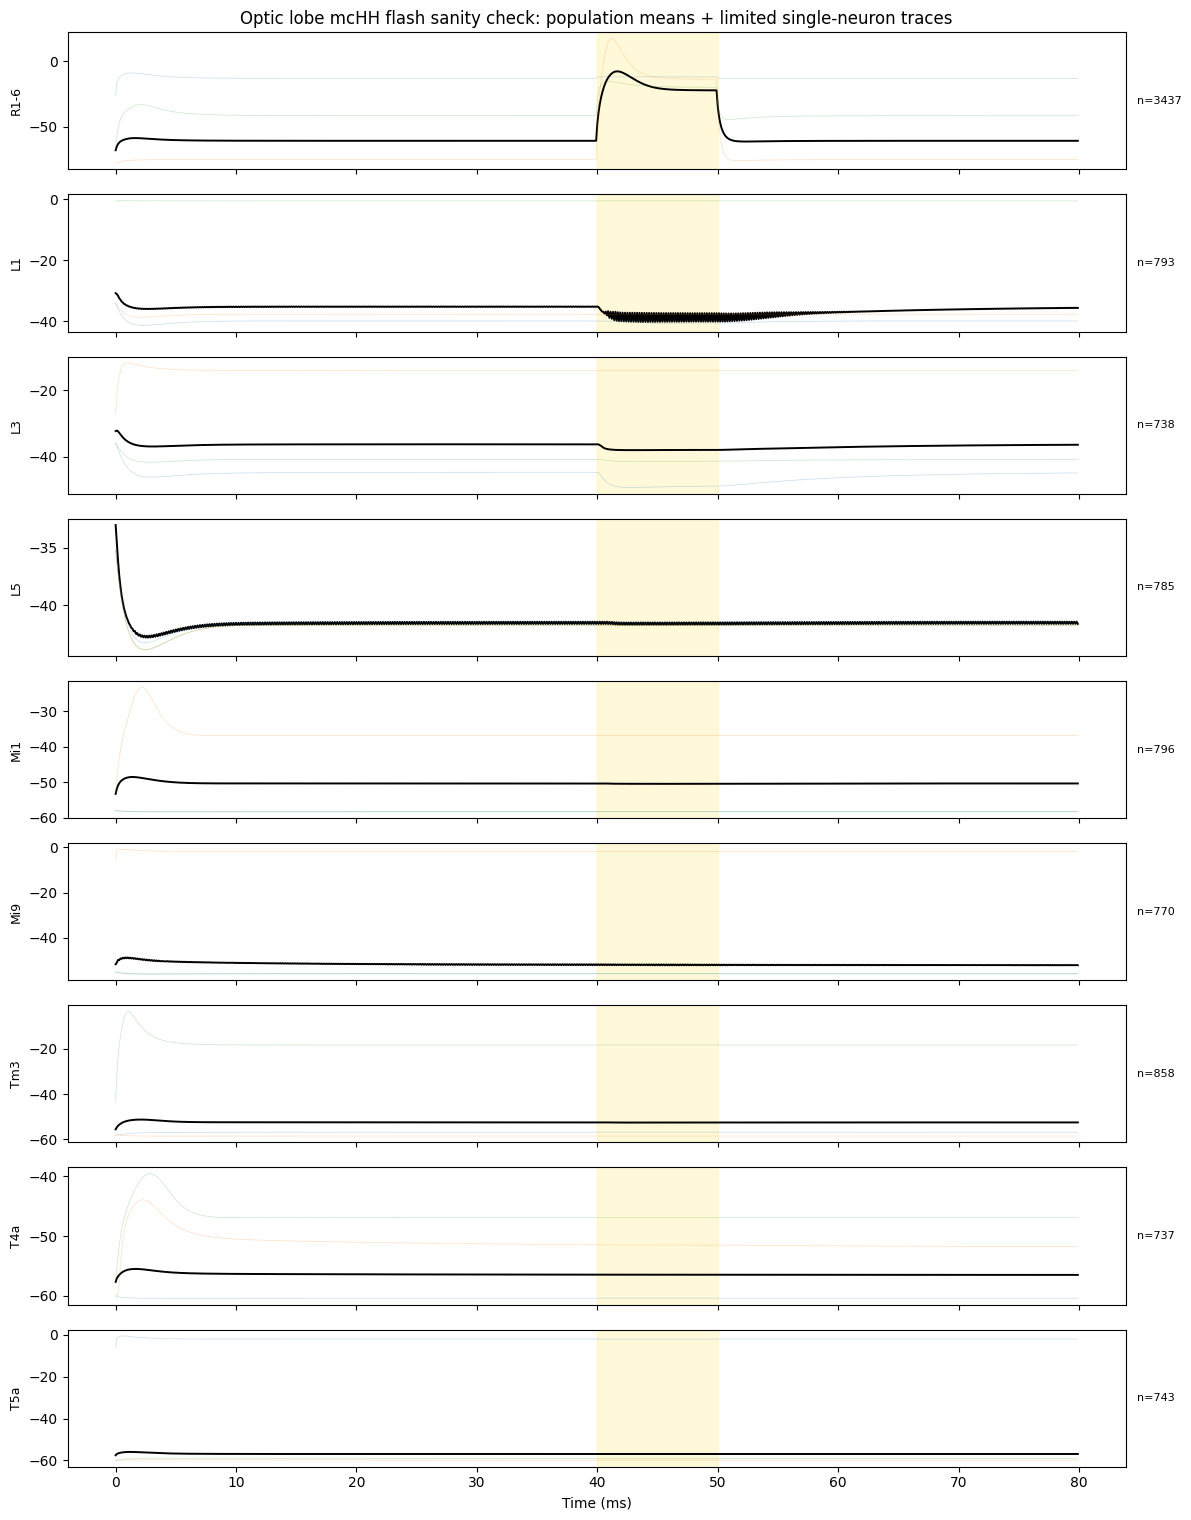

In [16]:
flash_type_summary = summarize_flash_by_type(net, V, flash_meta, show_types=SUMMARY_TYPES)
display(flash_type_summary)

t_ms = np.arange(V.shape[1]) * flash_meta['dt']
fig, axes = plt.subplots(len(SUMMARY_TYPES), 1, figsize=(12, 1.7 * len(SUMMARY_TYPES)), sharex=True)
if len(SUMMARY_TYPES) == 1:
    axes = [axes]

for ax, ct in zip(axes, SUMMARY_TYPES):
    idx = net.get_indices_by_type(ct)
    ax.set_ylabel(ct, fontsize=9)
    if not idx:
        continue

    vm = V[0, :, idx].mean(dim=1).numpy()
    ax.plot(t_ms, vm, lw=1.4, color='black', label='population mean')

    for j in idx[:MAX_SINGLE_NEURON_TRACES_PER_TYPE]:
        ax.plot(t_ms, V[0, :, j].numpy(), lw=0.5, alpha=0.25)

    ax.axvspan(
        flash_meta['t_on_s'] * flash_meta['dt'],
        flash_meta['t_on_e'] * flash_meta['dt'],
        color='gold', alpha=0.15,
    )
    ax.text(1.01, 0.5, f'n={len(idx)}', transform=ax.transAxes, va='center', fontsize=8)

axes[-1].set_xlabel('Time (ms)')
axes[0].set_title('Optic lobe mcHH flash sanity check: population means + limited single-neuron traces')
plt.tight_layout(); plt.show()


## 5b. Example single-neuron responses

除了 population mean，也直接看少量具体 neuron 的轨迹。这里每个 type 只抽少数几个例子，避免把数千个 neuron 全部画出来。


,type,neuron_idx,root_id,baseline_mV,on_mV,off_mV,peak_max_mV,peak_min_mV
0,R1-6,26,720575940601049097,-12.674465,-11.852695,-12.990914,-8.860417,-25.898399
1,R1-6,402,720575940605160550,-75.217064,-7.877185,-74.843079,17.458294,-77.885880
2,R1-6,524,720575940605444576,-40.906113,-18.743694,-41.837624,-15.120848,-66.635101
3,L1,48,720575940602857696,-39.969120,-40.375130,-39.996918,-34.033134,-41.331120
4,L1,273,720575940604747953,-37.713593,-37.697662,-37.669910,-33.856899,-38.680084
5,L1,356,720575940605032364,-0.478324,-0.480212,-0.480212,-0.423593,-0.851983
6,L3,308,720575940604889568,-44.661465,-48.638695,-45.995575,-35.822536,-49.152187
7,L3,443,720575940605268140,-14.029431,-14.104793,-14.104794,-11.820601,-27.077980
8,L3,445,720575940605273772,-40.743771,-41.296486,-40.879337,-35.785038,-41.584011
9,L5,121,720575940603923116,-41.646740,-41.552841,-41.552208,-35.139000,-43.268269


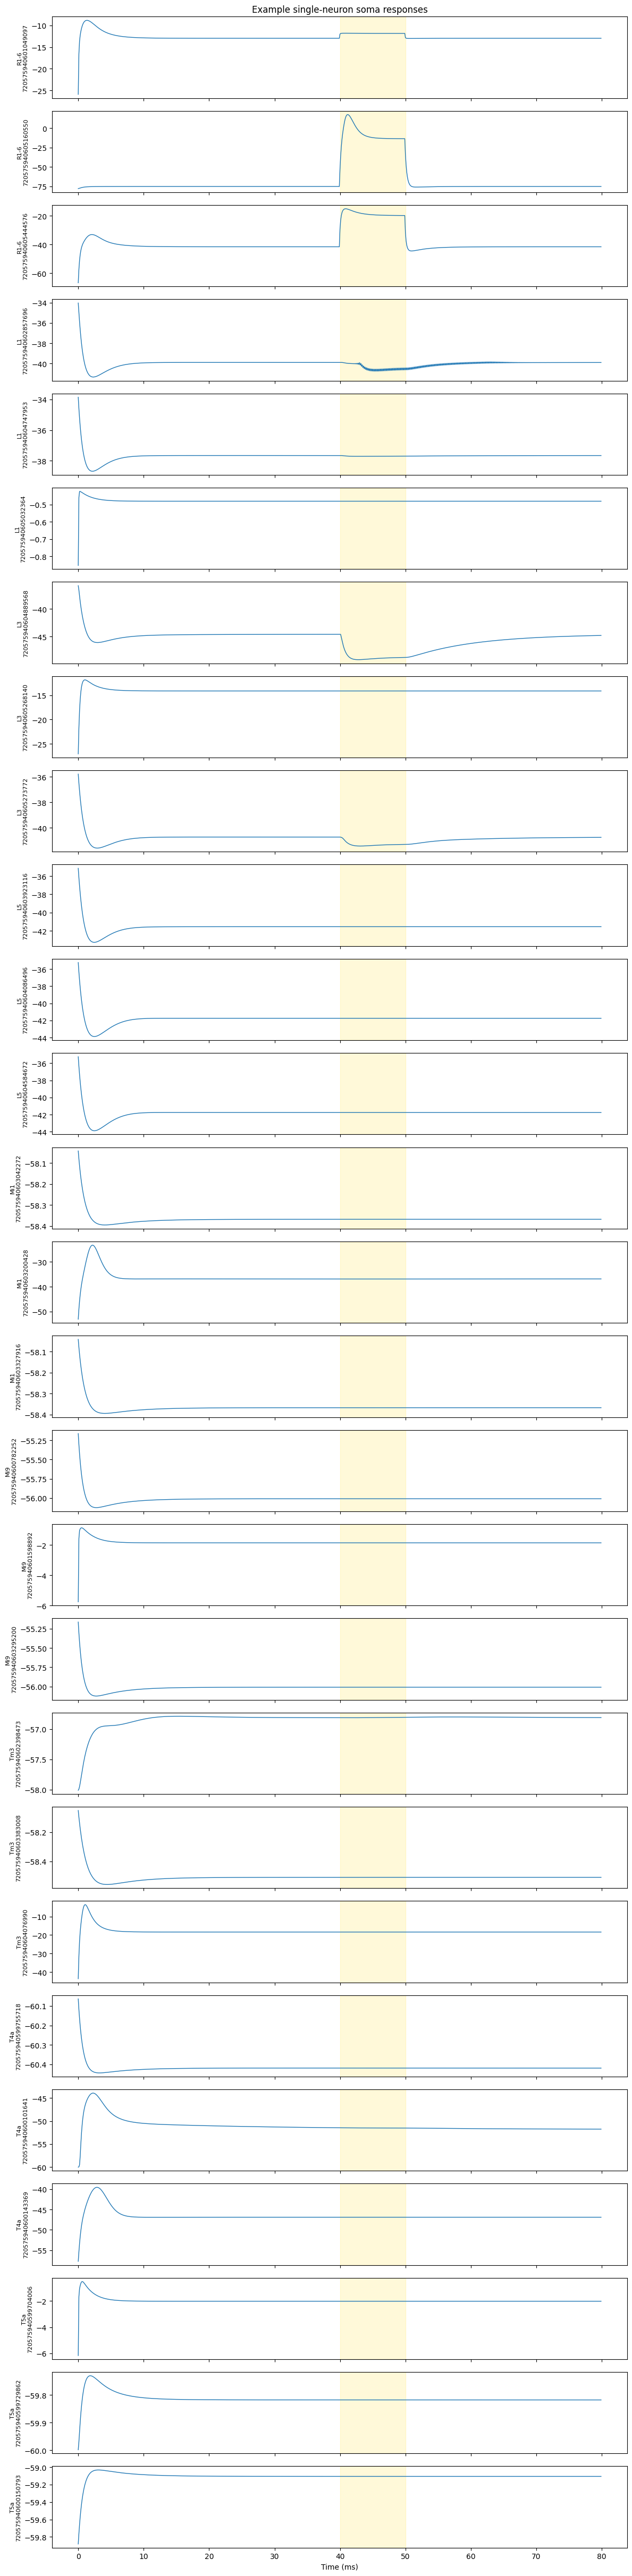

In [17]:
example_rows = []
for ct in SUMMARY_TYPES:
    idx = net.get_indices_by_type(ct)[:MAX_SINGLE_NEURON_TRACES_PER_TYPE]
    for j in idx:
        trace = V[0, :, j]
        example_rows.append({
            'type': ct,
            'neuron_idx': int(j),
            'root_id': int(net.root_ids[j]) if hasattr(net, 'root_ids') else j,
            'baseline_mV': float(trace[:flash_meta['t_on_s']].mean().item()) if flash_meta['t_on_s'] > 0 else float('nan'),
            'on_mV': float(trace[flash_meta['t_on_s']:flash_meta['t_on_e']].mean().item()) if flash_meta['t_on_e'] > flash_meta['t_on_s'] else float('nan'),
            'off_mV': float(trace[flash_meta['t_on_e']:].mean().item()) if flash_meta['t_on_e'] < trace.shape[0] else float('nan'),
            'peak_max_mV': float(trace.max().item()),
            'peak_min_mV': float(trace.min().item()),
        })

example_df = pd.DataFrame(example_rows)
display(example_df)

if len(example_rows) > 0:
    fig, axes = plt.subplots(len(example_rows), 1, figsize=(12, 1.8 * len(example_rows)), sharex=True)
    if len(example_rows) == 1:
        axes = [axes]

    for ax, row in zip(axes, example_rows):
        j = row['neuron_idx']
        trace = V[0, :, j].numpy()
        ax.plot(t_ms, trace, lw=1.0)
        ax.axvspan(
            flash_meta['t_on_s'] * flash_meta['dt'],
            flash_meta['t_on_e'] * flash_meta['dt'],
            color='gold', alpha=0.15,
        )
        ax.set_ylabel(f"{row['type']}\n{row['root_id']}", fontsize=8)

    axes[-1].set_xlabel('Time (ms)')
    axes[0].set_title('Example single-neuron soma responses')
    plt.tight_layout(); plt.show()


## 5d. Key pathway synapse audit

针对 optic lobe 关键通路，直接导出 edge-level synapse 参数，并结合当前 baseline voltage 估计这些 synapse 在刺激前的开关程度。


In [18]:
key_pathway_pairs = [
    ('R1-6', 'L1'),
    ('R1-6', 'L3'),
    ('R8', 'L1'),
    ('L1', 'Mi1'),
    ('L1', 'Tm3'),
    ('L3', 'Mi1'),
    ('L3', 'Mi9'),
    ('L5', 'L1'),
    ('L5', 'Mi1'),
    ('L5', 'Tm3'),
    ('Mi1', 'T4a'),
    ('Mi4', 'T4a'),
    ('Mi9', 'T4a'),
    ('Tm3', 'T4a'),
]

base_window = slice(0, flash_meta['t_on_s'])
base_soma = V[0, base_window].mean(dim=0) if flash_meta['t_on_s'] > 0 else V[0, 0]

edge_audit = pd.DataFrame({
    'pre_idx': net.pre_idx.detach().cpu().numpy(),
    'post_idx': net.post_idx.detach().cpu().numpy(),
    'pre_type': np.array(net.cell_types)[net.pre_idx.detach().cpu().numpy()],
    'post_type': np.array(net.cell_types)[net.post_idx.detach().cpu().numpy()],
    'pre_root_id': net.root_ids[net.pre_idx.detach().cpu().numpy()],
    'post_root_id': net.root_ids[net.post_idx.detach().cpu().numpy()],
    'syn_count': net.syn_count.detach().cpu().numpy(),
    'gS_mS_cm2': net.syn_gS.detach().cpu().numpy(),
    'e_syn_mV': net.syn_e_syn.detach().cpu().numpy(),
    'v_th_mV': net.syn_v_th.detach().cpu().numpy(),
    'k_minus': net.syn_k_minus.detach().cpu().numpy(),
    'delta_mV': net.syn_delta.detach().cpu().numpy(),
    'pre_baseline_mV': base_soma[net.pre_idx].detach().cpu().numpy(),
    'post_baseline_mV': base_soma[net.post_idx].detach().cpu().numpy(),
})
edge_audit['s_inf_baseline'] = 1.0 / (1.0 + np.exp((edge_audit['v_th_mV'] - edge_audit['pre_baseline_mV']) / edge_audit['delta_mV'].clip(lower=1e-3)))
edge_audit['tau_s_baseline_ms'] = (1.0 - edge_audit['s_inf_baseline']) / edge_audit['k_minus'].clip(lower=1e-6)
edge_audit['pair'] = list(zip(edge_audit['pre_type'], edge_audit['post_type']))
edge_audit['is_r16_output'] = edge_audit['pre_type'].isin(['R1-6', 'R1-R6'])

key_edge_audit = edge_audit[edge_audit['pair'].isin(key_pathway_pairs)].copy()
key_edge_summary = key_edge_audit.groupby(['pre_type', 'post_type'], as_index=False).agg(
    n_edges=('pair', 'size'),
    syn_count_mean=('syn_count', 'mean'),
    gS_mS_cm2_mean=('gS_mS_cm2', 'mean'),
    e_syn_mV_mean=('e_syn_mV', 'mean'),
    v_th_mV_mean=('v_th_mV', 'mean'),
    k_minus_mean=('k_minus', 'mean'),
    delta_mV_mean=('delta_mV', 'mean'),
    pre_baseline_mV_mean=('pre_baseline_mV', 'mean'),
    post_baseline_mV_mean=('post_baseline_mV', 'mean'),
    s_inf_baseline_mean=('s_inf_baseline', 'mean'),
    s_inf_baseline_median=('s_inf_baseline', 'median'),
    tau_s_baseline_ms_mean=('tau_s_baseline_ms', 'mean'),
)
key_edge_summary = key_edge_summary.sort_values(['pre_type', 'post_type']).reset_index(drop=True)

r16_edge_audit = edge_audit[edge_audit['is_r16_output']].copy()
r16_edge_summary = r16_edge_audit.groupby(['pre_type', 'post_type'], as_index=False).agg(
    n_edges=('pair', 'size'),
    syn_count_mean=('syn_count', 'mean'),
    gS_mS_cm2_mean=('gS_mS_cm2', 'mean'),
    e_syn_mV_mean=('e_syn_mV', 'mean'),
    v_th_mV_mean=('v_th_mV', 'mean'),
    k_minus_mean=('k_minus', 'mean'),
    delta_mV_mean=('delta_mV', 'mean'),
    pre_baseline_mV_mean=('pre_baseline_mV', 'mean'),
    post_baseline_mV_mean=('post_baseline_mV', 'mean'),
    s_inf_baseline_mean=('s_inf_baseline', 'mean'),
    s_inf_baseline_median=('s_inf_baseline', 'median'),
    tau_s_baseline_ms_mean=('tau_s_baseline_ms', 'mean'),
)
r16_edge_summary = r16_edge_summary.sort_values('post_type').reset_index(drop=True)

print('Key pathway synapse summary')
display(key_edge_summary)
print('All R1-6 output synapses')
display(r16_edge_summary)
print('Example R1-6 output edges')
display(r16_edge_audit.sort_values(['post_type', 'post_root_id']).head(40))

key_edge_summary.to_csv('../logs/optic_lobe_key_pathway_synapse_audit.csv', index=False)
key_edge_audit.to_csv('../logs/optic_lobe_key_pathway_synapse_edges.csv', index=False)
r16_edge_summary.to_csv('../logs/optic_lobe_r16_output_synapse_audit.csv', index=False)
r16_edge_audit.to_csv('../logs/optic_lobe_r16_output_synapse_edges.csv', index=False)
print('Saved: ../logs/optic_lobe_key_pathway_synapse_audit.csv')
print('Saved: ../logs/optic_lobe_key_pathway_synapse_edges.csv')
print('Saved: ../logs/optic_lobe_r16_output_synapse_audit.csv')
print('Saved: ../logs/optic_lobe_r16_output_synapse_edges.csv')


Key pathway synapse summary


,pre_type,post_type,n_edges,syn_count_mean,gS_mS_cm2_mean,e_syn_mV_mean,v_th_mV_mean,k_minus_mean,delta_mV_mean,pre_baseline_mV_mean,post_baseline_mV_mean,s_inf_baseline_mean,s_inf_baseline_median,tau_s_baseline_ms_mean
0,L1,Mi1,811,121.506783,0.50,-70.0,-45.0,0.08,4.0,-35.298706,-50.256439,0.783494,0.816289,2.706330
1,L1,Tm3,3385,20.247562,0.30,-70.0,-45.0,0.10,4.0,-34.924248,-52.474735,0.787524,0.816094,2.124756
2,L3,Mi1,748,18.779411,0.30,0.0,-45.0,0.14,3.0,-35.898415,-50.755341,0.749182,0.810089,1.791560
3,L3,Mi9,883,61.770103,0.30,0.0,-45.0,0.12,3.0,-36.016506,-51.379025,0.746939,0.810054,2.108844
4,L5,L1,795,33.397484,0.20,0.0,-45.0,0.10,4.0,-41.513779,-35.237141,0.573878,0.684919,4.261224
5,L5,Mi1,993,38.210472,0.50,0.0,-45.0,0.10,4.0,-41.377560,-50.288288,0.576263,0.684919,4.237366
6,L5,Tm3,3144,13.572519,0.50,0.0,-45.0,0.10,4.0,-41.117683,-52.219948,0.578962,0.684919,4.210376
7,Mi1,T4a,2655,16.200001,0.40,0.0,-48.0,0.18,3.8,-50.088814,-56.259693,0.258155,0.072750,4.121362
8,Mi4,T4a,609,7.357964,8.00,-72.0,-55.0,0.03,3.2,-53.696369,-56.590240,0.340382,0.179285,21.987283
9,Mi9,T4a,787,8.559085,2.00,-70.0,-40.0,0.03,3.5,-51.549690,-56.534271,0.112646,0.010193,29.578461


All R1-6 output synapses


,pre_type,post_type,n_edges,syn_count_mean,gS_mS_cm2_mean,e_syn_mV_mean,v_th_mV_mean,k_minus_mean,delta_mV_mean,pre_baseline_mV_mean,post_baseline_mV_mean,s_inf_baseline_mean,s_inf_baseline_median,tau_s_baseline_ms_mean
0,R1-6,C2,5,5.400000,0.70,-72.0,-52.0,0.1,3.0,-48.008385,-44.398693,0.400110,0.000205,5.998900
1,R1-6,C3,12,5.250000,0.70,-72.0,-52.0,0.1,3.0,-51.887287,-39.636440,0.406762,0.003914,5.932383
2,R1-6,L1,3422,42.492111,1.20,-72.0,-56.0,0.1,3.0,-60.572464,-35.042450,0.308676,0.001004,6.913236
3,R1-6,L2,3433,52.004368,0.80,-72.0,-52.0,0.1,3.0,-60.690422,-35.703289,0.288236,0.000261,7.117642
4,R1-6,L3,3203,24.514517,0.75,-72.0,-56.0,0.1,3.0,-60.598503,-36.103500,0.306893,0.001021,6.931071
5,R1-6,L4,9,9.555555,0.60,-72.0,-52.0,0.1,3.0,-44.895702,-40.595097,0.555136,0.995881,4.448640
6,R1-6,L5,3,10.333333,0.70,-72.0,-52.0,0.1,3.0,-53.247753,-50.053864,0.333481,0.000240,6.665192
7,R1-6,Lai,3589,23.755085,0.70,-72.0,-52.0,0.1,3.0,-60.359745,-44.431015,0.291584,0.000273,7.084160
8,R1-6,R1-6,190,6.510526,0.70,-72.0,-52.0,0.1,3.0,-60.976944,-59.424168,0.279197,0.000289,7.208028
9,R1-6,R7,2,6.500000,0.70,-72.0,-52.0,0.1,3.0,-40.718426,-68.017014,0.500197,0.500197,4.998029


Example R1-6 output edges


,pre_idx,post_idx,pre_type,post_type,pre_root_id,post_root_id,syn_count,gS_mS_cm2,e_syn_mV,v_th_mV,k_minus,delta_mV,pre_baseline_mV,post_baseline_mV,s_inf_baseline,tau_s_baseline_ms,pair,is_r16_output
130887,4994,16916,R1-6,C2,720575940612747889,720575940621571199,6.0,0.7,-72.0,-52.0,0.1,3.0,-0.655644,-41.894108,1.000000,3.690989e-07,"(R1-6, C2)",True
639907,41616,17115,R1-6,C2,720575940637454222,720575940621660144,6.0,0.7,-72.0,-52.0,0.1,3.0,-77.982582,-41.073330,0.000173,9.998268e+00,"(R1-6, C2)",True
873866,8931,32625,R1-6,C2,720575940616297119,720575940629985128,5.0,0.7,-72.0,-52.0,0.1,3.0,-5.924229,-55.237728,1.000000,2.137219e-06,"(R1-6, C2)",True
103212,42976,36394,R1-6,C2,720575940639165156,720575940632224908,5.0,0.7,-72.0,-52.0,0.1,3.0,-78.001076,-41.894077,0.000172,9.998278e+00,"(R1-6, C2)",True
389527,13539,39563,R1-6,C2,720575940619750966,720575940634966463,5.0,0.7,-72.0,-52.0,0.1,3.0,-77.478401,-41.894230,0.000205,9.997951e+00,"(R1-6, C2)",True
473554,28446,1541,R1-6,C3,720575940627721624,720575940607471538,6.0,0.7,-72.0,-52.0,0.1,3.0,-77.822853,-41.893627,0.000183,9.998173e+00,"(R1-6, C3)",True
507205,32145,3036,R1-6,C3,720575940629723139,720575940610426051,5.0,0.7,-72.0,-52.0,0.1,3.0,-77.968620,-41.894108,0.000174,9.998260e+00,"(R1-6, C3)",True
303759,36534,3609,R1-6,C3,720575940632318250,720575940611274725,5.0,0.7,-72.0,-52.0,0.1,3.0,-44.454056,-41.672714,0.925208,7.479150e-01,"(R1-6, C3)",True
1034130,32406,4639,R1-6,C3,720575940629880475,720575940612455282,5.0,0.7,-72.0,-52.0,0.1,3.0,-43.339863,-41.894009,0.947186,5.281434e-01,"(R1-6, C3)",True
653451,37925,5698,R1-6,C3,720575940633255199,720575940613373667,5.0,0.7,-72.0,-52.0,0.1,3.0,-66.750839,-41.894005,0.007268,9.927317e+00,"(R1-6, C3)",True


Saved: ../logs/optic_lobe_key_pathway_synapse_audit.csv
Saved: ../logs/optic_lobe_key_pathway_synapse_edges.csv
Saved: ../logs/optic_lobe_r16_output_synapse_audit.csv
Saved: ../logs/optic_lobe_r16_output_synapse_edges.csv


## 5c. Diagnostic checks for suspicious responses

如果 response 看起来不对，优先检查三件事：
1. baseline membrane potential 是否已经过高
2. synapse 的 `s_inf` 在 baseline 是否已经接近 fully open
3. 是否有不少 neuron 在仿真中碰到 voltage clamp (`-120` 或 `80`)


In [19]:
V0 = V[0]
base_window = slice(0, flash_meta['t_on_s'])
base_soma = V0[base_window].mean(dim=0) if flash_meta['t_on_s'] > 0 else V0[0]

# Edge-level synaptic steady state under baseline voltages.
pre_v_edge = base_soma[net.pre_idx].double()
syn_delta = net.syn_delta.double().clamp(min=0.1)
s_inf_base = 1.0 / (1.0 + torch.exp((net.syn_v_th.double() - pre_v_edge) / syn_delta))

clamped_low = (V0.min(dim=0).values <= -119.9)
clamped_high = (V0.max(dim=0).values >= 79.9)

edge_diag = pd.Series({
    's_inf mean': float(s_inf_base.mean().item()),
    's_inf median': float(s_inf_base.median().item()),
    'edges with s_inf > 0.50': float((s_inf_base > 0.50).float().mean().item()),
    'edges with s_inf > 0.90': float((s_inf_base > 0.90).float().mean().item()),
})

neuron_diag = pd.Series({
    'baseline soma mean (mV)': float(base_soma.mean().item()),
    'baseline soma median (mV)': float(base_soma.median().item()),
    'neurons touching -120 mV': int(clamped_low.sum().item()),
    'neurons touching +80 mV': int(clamped_high.sum().item()),
    'fraction touching -120 mV': float(clamped_low.float().mean().item()),
    'fraction touching +80 mV': float(clamped_high.float().mean().item()),
})

print('Edge-level diagnostic summary')
display(edge_diag.to_frame('value'))
print('Neuron-level diagnostic summary')
display(neuron_diag.to_frame('value'))

extreme_df = pd.DataFrame({
    'root_id': net.root_ids,
    'type': net.cell_types,
    'baseline_mV': base_soma.cpu().numpy(),
    'v_min_mV': V0.min(dim=0).values.cpu().numpy(),
    'v_max_mV': V0.max(dim=0).values.cpu().numpy(),
    'clamped_low': clamped_low.cpu().numpy(),
    'clamped_high': clamped_high.cpu().numpy(),
})

display(extreme_df.sort_values('v_max_mV', ascending=False).head(15))
display(extreme_df.sort_values('v_min_mV', ascending=True).head(15))

print('Interpretation hints:')
print('- If baseline soma voltages are already close to synaptic v_th, many synapses are tonically on, so flash modulation becomes weak.')
print('- If many neurons hit -120 or +80 mV, the current parameterization is likely too strong or numerically imbalanced for part of the network.')
print('- If R1-6 remains weak while the network is stable, rerun the sanity check with STRONG_SANITY_I_AMP.')


Edge-level diagnostic summary


,value
s_inf mean,0.323265
s_inf median,0.173199
edges with s_inf > 0.50,0.339825
edges with s_inf > 0.90,0.094998


Neuron-level diagnostic summary


,value
baseline soma mean (mV),-51.079464
baseline soma median (mV),-52.005234
neurons touching -120 mV,120.000000
neurons touching +80 mV,1.000000
fraction touching -120 mV,0.002537
fraction touching +80 mV,0.000021


,root_id,type,baseline_mV,v_min_mV,v_max_mV,clamped_low,clamped_high
39854,720575940635241908,Tm9,-21.075483,-120.000000,80.000000,True,True
525,720575940605444966,Tm9,-26.020489,-120.000000,78.524727,True,False
45756,720575940645393006,Mi9,-30.749834,-120.000000,75.554489,True,False
12304,720575940618751312,Tm9,-34.156666,-120.000000,74.491882,True,False
39229,720575940634572384,R8,-68.072014,-71.667870,60.657360,False,False
43821,720575940640218702,R8,-68.072014,-71.667847,60.656910,False,False
37116,720575940632662329,R8,-68.072014,-71.667839,60.656689,False,False
28422,720575940627709565,R8,-68.071510,-71.667480,60.656635,False,False
30333,720575940628632337,R8,-68.072014,-71.667816,60.656128,False,False
7503,720575940615021352,R8,-68.070946,-71.667419,60.655689,False,False


,root_id,type,baseline_mV,v_min_mV,v_max_mV,clamped_low,clamped_high
4518,720575940612349363,L1,-58.593178,-120.0,-21.101347,True,False
9728,720575940616960699,L1,-52.000195,-120.0,-31.427345,True,False
40079,720575940635493999,L1,-59.829639,-120.0,-16.565266,True,False
8047,720575940615494303,Tm9,-42.072369,-120.0,53.168385,True,False
5844,720575940613513330,L1,-34.346500,-120.0,-28.456398,True,False
21036,720575940623686792,L1,-60.017990,-120.0,-21.203838,True,False
45756,720575940645393006,Mi9,-30.749834,-120.0,75.554489,True,False
10046,720575940617209980,Mi9,-63.348804,-120.0,-20.128206,True,False
31068,720575940629039100,L1,-55.310436,-120.0,-24.053179,True,False
32789,720575940630089115,L1,-53.964809,-120.0,-24.719814,True,False


Interpretation hints:
- If baseline soma voltages are already close to synaptic v_th, many synapses are tonically on, so flash modulation becomes weak.
- If many neurons hit -120 or +80 mV, the current parameterization is likely too strong or numerically imbalanced for part of the network.
- If R1-6 remains weak while the network is stable, rerun the sanity check with STRONG_SANITY_I_AMP.


In [20]:
net.n_neurons, net.n_edges


(47291, 1111323)